# Synent Task 3: Netflix Content Analysis
**Dataset:** Netflix Movies and TV Shows
**Objective:** Explore Netflix titles and explain catalog patterns using charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid')

df = pd.read_csv('netflix_titles.csv')
print('Shape:', df.shape)
df.head()

Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 1. Dataset Overview

In [2]:
print('Dataset Info:')
df.info()
print('\nMissing Values:\n', df.isnull().sum())
print('\nBasic Stats:')
df.describe(include='all')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB

Missing Values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 2. Preparing Fields for Analysis

In [3]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['duration'].fillna('Unknown', inplace=True)

print('Missing values after cleaning:\n', df.isnull().sum())

Missing values after cleaning:
 show_id            0
type               0
title              0
director        2634
cast             825
country            0
date_added        10
release_year       0
rating             0
duration           0
listed_in          0
description        0
year_added        10
dtype: int64


C:\Users\D ABHIRAM\AppData\Local\Temp\ipykernel_4412\199792039.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)
C:\Users\D ABHIRAM\AppData\Local\Temp\ipykernel_4412\199792039.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

## 3. Content Type Split

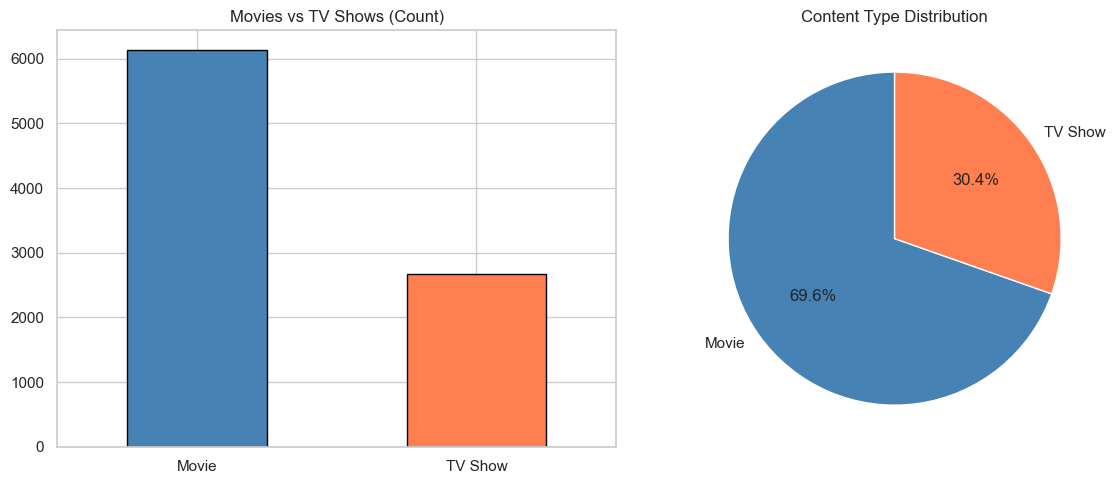

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [4]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

type_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Movies vs TV Shows (Count)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(type_counts.index, rotation=0)

axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Content Type Distribution')

plt.tight_layout()
plt.savefig('movies_vs_shows.png', dpi=150)
plt.show()
print(type_counts)

## 4. Countries Contributing Most Titles

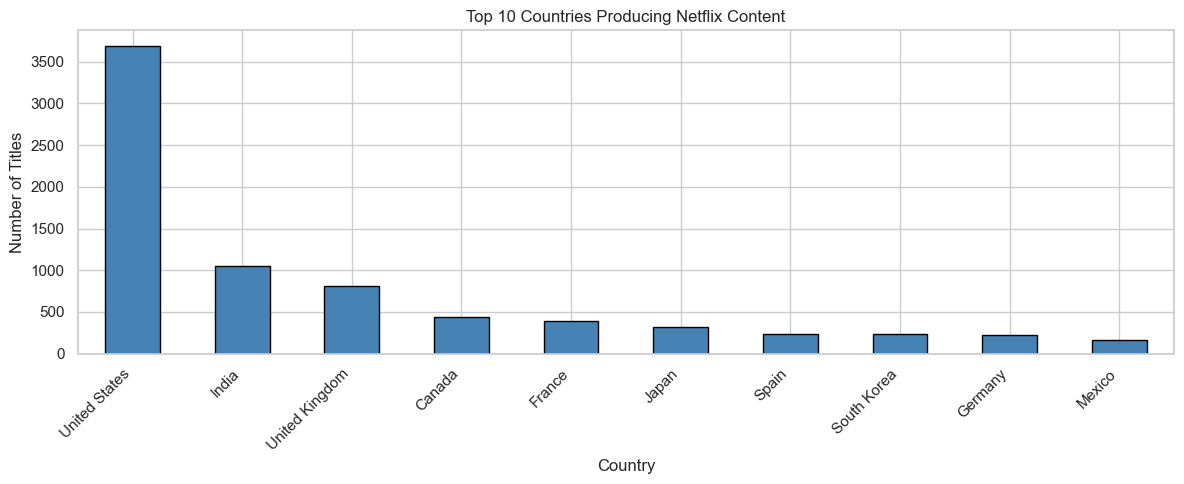

In [5]:
country_series = df['country'].str.split(',').explode().str.strip()
top_countries = country_series[country_series != 'Unknown'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_countries.png', dpi=150)
plt.show()

## 5. Yearly Content Addition Trend

<Figure size 1200x500 with 0 Axes>

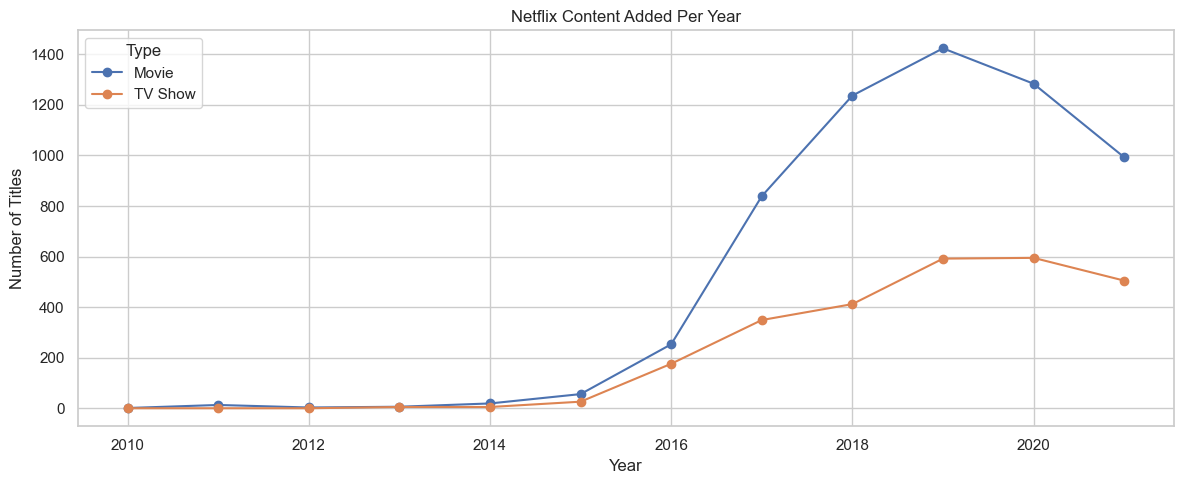

In [6]:
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2010]

plt.figure(figsize=(12, 5))
yearly.plot(kind='line', marker='o', figsize=(12, 5))
plt.title('Netflix Content Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.tight_layout()
plt.savefig('content_trend.png', dpi=150)
plt.show()

## 6. Rating Breakdown

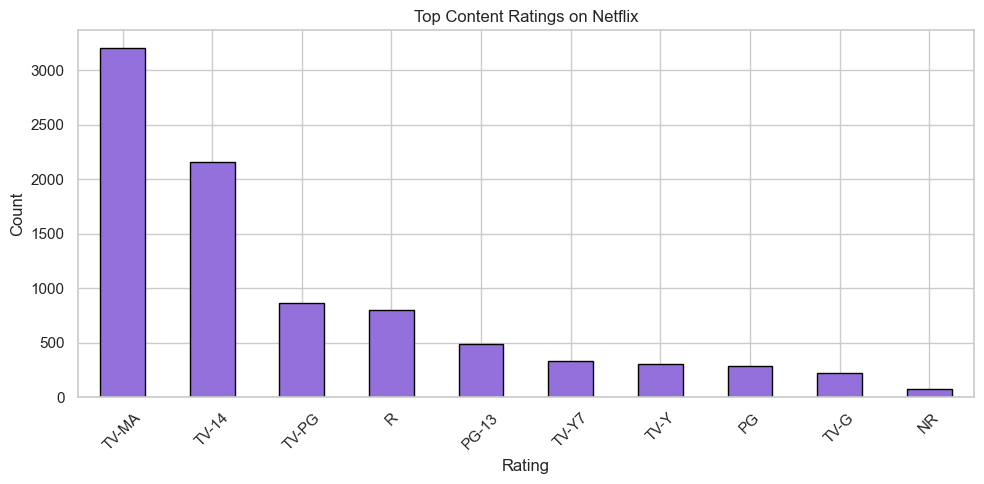

In [7]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure(figsize=(10, 5))
rating_counts.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Top Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rating_dist.png', dpi=150)
plt.show()

## 7. Common Genre Labels

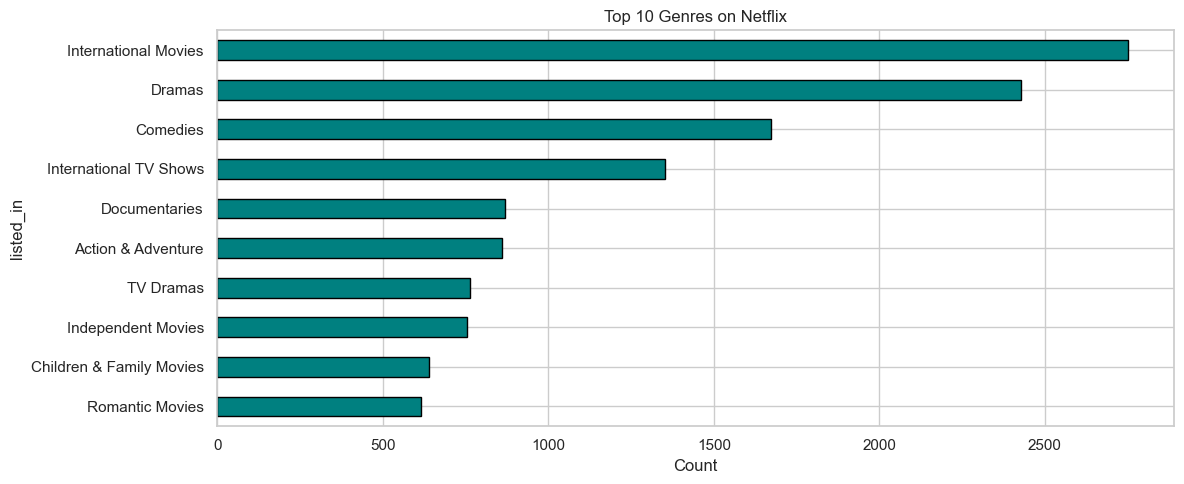

In [8]:
genre_series = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genre_series.value_counts().head(10)

plt.figure(figsize=(12, 5))
top_genres.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_genres.png', dpi=150)
plt.show()

## 8. Final Insight Summary

In [9]:
print('=== NETFLIX ANALYSIS INSIGHTS ===')
print(f"Total titles: {len(df)}")
print(f"Movies: {type_counts.get('Movie', 0)} | TV Shows: {type_counts.get('TV Show', 0)}")
print(f"Top country: {top_countries.index[0]} with {top_countries.iloc[0]} titles")
print(f"Most common rating: {rating_counts.index[0]}")
print(f"Top genre: {top_genres.index[0]}")
print(f"Peak year of content addition: {yearly.sum(axis=1).idxmax()}")

=== NETFLIX ANALYSIS INSIGHTS ===
Total titles: 8807
Movies: 6131 | TV Shows: 2676
Top country: United States with 3690 titles
Most common rating: TV-MA
Top genre: International Movies
Peak year of content addition: 2019.0
